In [1]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic
from popsycle import utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import synthpop
import pdb
import time

# SynthPop

This is where you generate the stellar model. Start by initializing SynthPop object with the configuration of your choice.
This may take a few minutes if it needs to download isochrones and/or several seconds to load a large extinction map file.

For PopSyCLE, it is required to use the popsycle_post_processing module to get your data in the right format. Additionally, you must use absolute magnitudes and use filters that PopSyCLE can interpret.

In [2]:
sp_mod = synthpop.SynthPop('huston2025_defaults.synthpop_conf', # set default figuration, then set any overrides as kwargs
                           output_location="synthpop_output",  # where to place the synthpop output
                           obsmag = False, # keep magnitudes in absolute
                           name_for_output='synthpopsycle', output_filename_pattern="{name_for_output}_l{l_deg:.3f}_b{b_deg:.3f}", #how to name the output
                           post_processing_kwargs = [{"name":"ProcessDarkCompactObjects", "remove":False, "ifmr_name":'SukhboldN20',
                                                     "kick_mean_ns":350, "kick_mean_bh":100}, # IFMR + kick velocities
                                {"name": "popsycle_post_processing"}], # Module to format catalog for PopSyCLE
                           chosen_bands=["Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I", "2MASS_J", "2MASS_H", "2MASS_Ks"],
                           maglim=['Bessell_U',99,'keep'],
                           extinction_map_kwargs = {"name":"maps_from_dustmaps", "dustmap_name":"marshall"} #{"name":"surot"}
                          )
sp_mod.init_populations()

 10383 - Execution Date: 09-09-2025 14:27:41


################################ Settings #################################
 10386 - # reading default parameters from
 10388 - default_config_file =  /u/mhuston/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 10393 - # read configuration from 
 10395 - config_file = '/u/mhuston/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 10398 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "synthpopsycle",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 1993927877,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4,

Then, run the specific sightline you want

In [3]:
t0=time.time()
_ = sp_mod.process_location(1, -1.2, # first, enter l and b in degrees
                            solid_angle=1e-3, solid_angle_unit='deg^2', # solid angle can be in deg^2 or sr
                            save_data=False) # this prevents synthpop from saving in its default format, it will already be saved via popsycle_post_processing
print(f'Synthpop catalog generated in {np.round((time.time()-t0)/60, 2)} minutes.')



############################# update location #############################
 36620 - # set location to: 
 36622 - l, b = (1.00 deg, -1.20 deg)
 36624 - # set solid_angle to:
 36626 - solid_angle = 1.000e-03 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 49343 - # From density profile (number density)
 49346 - expected_total_iMass = 404149.1758
 49348 - expected_total_eMass = 220493.1658
 49350 - average_iMass_per_star = 0.5739
 49352 - mass_loss_correction = 0.5456
 49354 - n_expected_stars = 704257.1067
 49360 - # Determine velocities when position are generated 


  0%|          | 0/704252 [00:00<?, ?it/s]

 64765 - # From Generated Field:
 64767 - generated_stars = 704252
 64789 - generated_total_iMass = 402395.7820
 64840 - generated_total_eMass = 220901.8351
 64859 - det_mass_loss_corr = 0.5490
 65914 - # Done


# Population 1;  halo -----------------------------------------------------
 66558 - # From density profile (number density)
 66561 - expected_total_iMass = 535.1923
 66563 - expected_total_eMass = 281.7842
 66565 - average_iMass_per_star = 0.5739
 66567 - mass_loss_correction = 0.5265
 66569 - n_expected_stars = 932.6085
 66574 - # Determine velocities when position are generated 
 66714 - # From Generated Field:
 66716 - generated_stars = 943
 66719 - generated_total_iMass = 536.0138
 66730 - generated_total_eMass = 282.5659
 66732 - det_mass_loss_corr = 0.5272
 66808 - # Done


# Population 2;  nsd ------------------------------------------------------
 68360 - # From density profile (number density)
 68362 - expected_total_iMass = 2050.8050
 68364 - expected_total_eMass = 1

PopSyCLE formatted output saved in synthpop_output/synthpopsycle_l1.000_b-1.200_psc.h5
Synthpop catalog generated in 0.88 minutes.


# Finding microlensing events

Here is when all microlensing events are found.
You can set the survey duration, cadence, maximum impact parameter, blend radius.
This also has the option of being parallelizable.

In [4]:
synthetic.calc_events(hdf5_file = "synthpop_output/synthpopsycle_l1.000_b-1.200_psc.h5", 
                      output_root2 = 'synthpop_output/synthpopsycle_l1.000_b-1.200_psc', 
                      radius_cut = 2, 
                      obs_time = 1000, 
                      n_obs = 11, 
                      theta_frac = 2, 
                      blend_rad = 0.65, 
                      overwrite = True, 
                      n_proc = 4)

Working on loop ll, bb =  0 0
Candidate events detected:  156
calc_events runtime : 39.351228 s


# Photometry

This is the last thing, where you choose the photometric band for the observations and the reddening law.
The final file of microlensing events is produced here as a .fits file.

In [5]:
synthetic.refine_events(input_root = 'synthpop_output/synthpopsycle_l1.000_b-1.200_psc', 
                        filter_name = 'I',
                        photometric_system = 'ubv',
                        red_law = 'Damineli16', 
                        overwrite = True, 
                        output_file = 'default',
                        galactic_model_code = 'synthpop')

Original candidate events:  123
Candidate events in survey window:  101
refine_events runtime : 0.381826 s


# Things you can do with PopSyCLE

First, read in the table, and print out a list of all the possible keys:

In [6]:
t = Table.read('synthpop_output/synthpopsycle_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16.fits')
print(t.colnames)

['zams_mass_L', 'mass_L', 'systemMass_L', 'px_L', 'py_L', 'pz_L', 'vx_L', 'vy_L', 'vz_L', 'vr_L', 'mu_lcosb_L', 'mu_b_L', 'exbv_L', 'glat_L', 'glon_L', 'mbol_L', 'grav_L', 'teff_L', 'feh_L', 'rad_L', 'ubv_U_L', 'ubv_B_L', 'ubv_V_L', 'ubv_R_L', 'ubv_I_L', 'ubv_J_L', 'ubv_H_L', 'ubv_K_L', 'isMultiple_L', 'N_companions_L', 'rem_id_L', 'obj_id_L', 'zams_mass_S', 'mass_S', 'systemMass_S', 'px_S', 'py_S', 'pz_S', 'vx_S', 'vy_S', 'vz_S', 'vr_S', 'mu_lcosb_S', 'mu_b_S', 'exbv_S', 'glat_S', 'glon_S', 'mbol_S', 'grav_S', 'teff_S', 'feh_S', 'rad_S', 'ubv_U_S', 'ubv_B_S', 'ubv_V_S', 'ubv_R_S', 'ubv_I_S', 'ubv_J_S', 'ubv_H_S', 'ubv_K_S', 'isMultiple_S', 'N_companions_S', 'rem_id_S', 'obj_id_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed']


## Figure out how many events due to BH, NS, WD, star

In [7]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 1
Number of NSs: 3
Number of WDs: 13
Number of stars: 84


## Histogram of tE

Text(0.5, 0, '$t_E$ (days)')

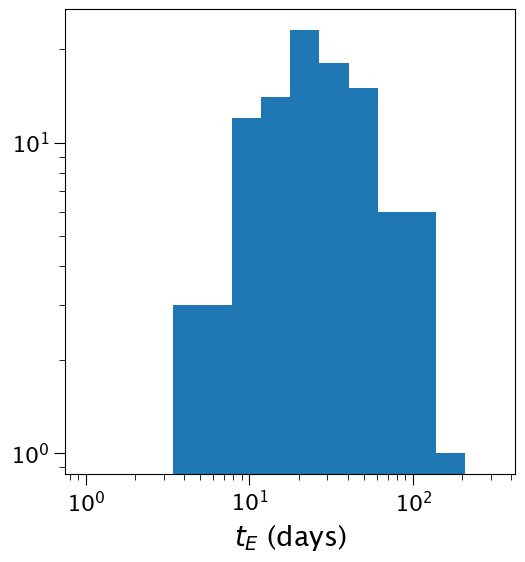

In [8]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

## piE vs tE

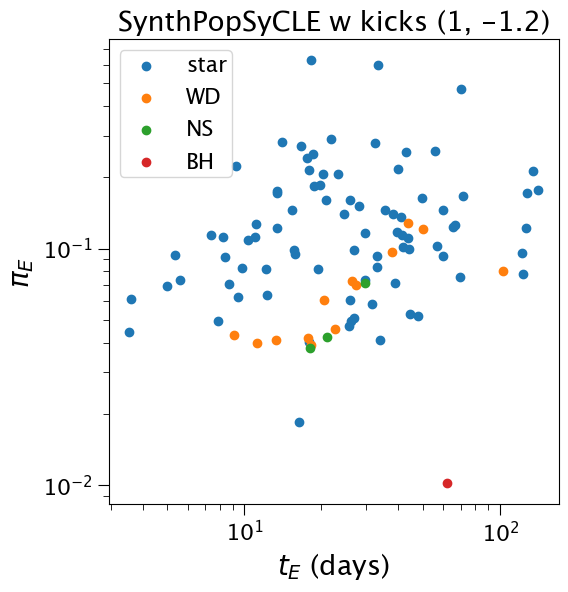

In [9]:
lens_type={0:'star', 101:'WD', 102:'NS', 103:'BH'}
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['t_E'][idxs], t['pi_E'][idxs], label=lens_type[rem_id])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')
plt.legend(loc=2)
plt.title('SynthPopSyCLE w kicks (1, -1.2)')
plt.savefig('synthpopsycle_lenstype.png')

## dL vs dS

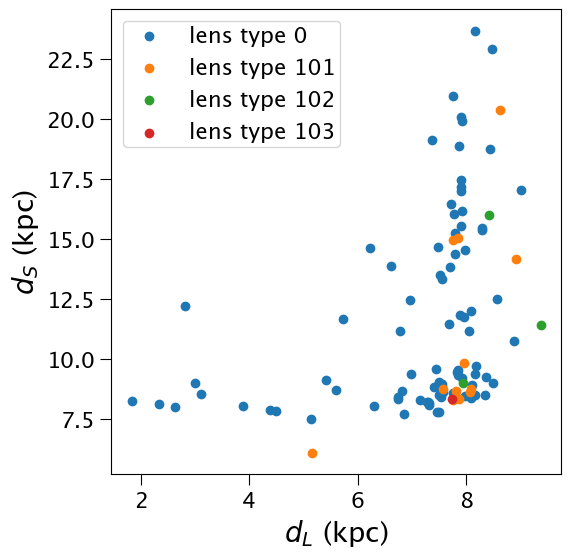

In [10]:
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['rad_L'][idxs], t['rad_S'][idxs], label='lens type '+str(rem_id))
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')
plt.legend()